<a href="https://colab.research.google.com/github/IsaacGSolis/Mineria-de-Datos-IEGS/blob/main/KMeansE2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [10]:
#1 Crear Dataframe
data={
    'ejercicio':[0.5, 1, 1.5, 6, 7, 8, 2, 3, 4],
    'condicion':[2, 3, 2.5, 8, 9, 10, 4, 5, 6]
}
df=pd.DataFrame(data)
#2 Mostrar datos
df

,ejercicio,condicion
0,0.5,2.0
1,1.0,3.0
2,1.5,2.5
3,6.0,8.0
4,7.0,9.0
5,8.0,10.0
6,2.0,4.0
7,3.0,5.0
8,4.0,6.0


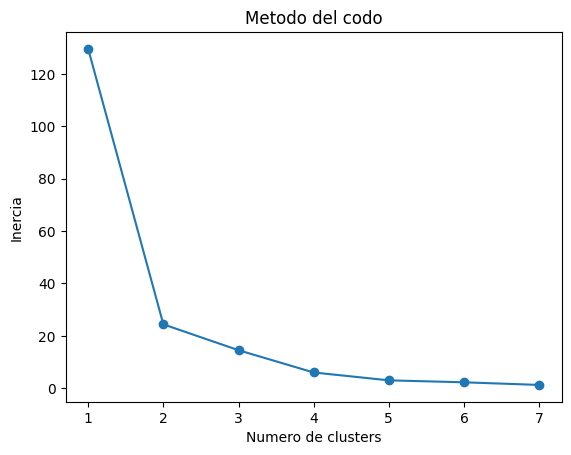

In [11]:
#3 Metodo del codo
X=df[['ejercicio', 'condicion']].values
inercias=[]
for k in range(1, 8):
    kmeans=KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)

#Graficar el metodo del codo (Identificar clusters)
plt.plot(range(1, 8), inercias, marker='o')
plt.xlabel('Numero de clusters')
plt.ylabel('Inercia')
plt.title('Metodo del codo')
plt.show()

In [12]:
kmeans=KMeans(n_clusters=2, random_state=42)
df['cluster']=kmeans.fit_predict(X)
df

,ejercicio,condicion,cluster
0,0.5,2.0,1
1,1.0,3.0,1
2,1.5,2.5,1
3,6.0,8.0,0
4,7.0,9.0,0
5,8.0,10.0,0
6,2.0,4.0,1
7,3.0,5.0,1
8,4.0,6.0,1


In [13]:
#5 Obtener centroides
centroides=kmeans.cluster_centers_
centroides

array([[7.  , 9.  ],
       [2.  , 3.75]])

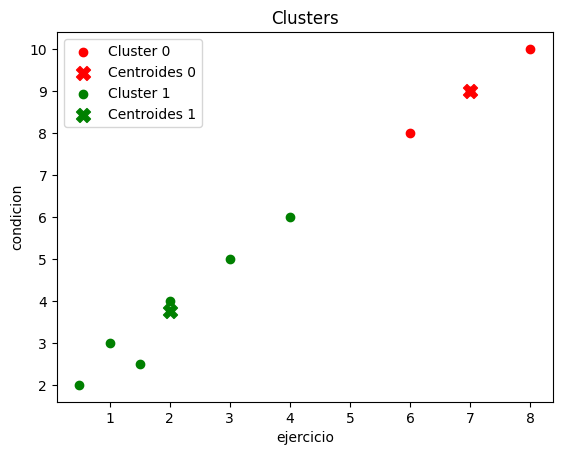

In [14]:
#6 Graficar cluster con sus centroides
colores=['red', 'green']
for i in range(2):
    cluster=df[df['cluster']==i]
    plt.scatter(cluster['ejercicio'], cluster['condicion'], color=colores[i], label=f'Cluster {i}')
    plt.scatter(centroides[i, 0], centroides[i, 1], c=colores[i], marker='X',s=100,label=f'Centroides {i}')
plt.xlabel('ejercicio')
plt.ylabel('condicion')
plt.title('Clusters')
plt.legend()
plt.show()

**¿Cómo describirías cada grupo de personas?**

Grupo 1 (Cluster 0): Personas con baja o media condicion fisica en base al tiempo de ejercicio que realizan.

Grupo 2 (Cluster 1): Personas con bueno o alta condicion/rendimiento fisico(a) en base al tiempo de ejercicio que realiza